In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# параметры
c = 5850
f = 1000000
lmbd = c / f
k = 2 * np.pi / lmbd + 0j
b = 0.001
N = 50

In [29]:
2 * b / lmbd

0.3418803418803419

In [30]:
# сетка
y = np.linspace(0, 2 * b, 200)
z = np.linspace(-0.1, 0.1, 500)

Z, Y = np.meshgrid(z, y)

In [31]:
# =========================
# ВСПОМОГАТЕЛЬНЫЕ ВЕКТОРЫ
# =========================
n = np.arange(1, N + 1)
n_half = n - 0.5

# gamma
gamma_n = np.sqrt((n * np.pi / b)**2 - k**2)
gamma_n_half = np.sqrt((n_half * np.pi / b)**2 - k**2)

# =========================
# K_plus (с кешированием вручную)
# =========================
def K_plus(alpha):
    res = 1.0
    for m in range(1, N + 1):
        num = np.sqrt(1 - k**2 * (b / ((m - 0.5) * np.pi))**2) - 1j * alpha * (b / ((m - 0.5) * np.pi))
        den = np.sqrt(1 - k**2 * (b / (m * np.pi))**2) - 1j * alpha * (b / (m * np.pi))
        res *= num / den
    return res

# считаем один раз
Kk = K_plus(k)

# коэффициенты
P0 = 0.5 * (1 + Kk**(-2))

K_gamma = np.array([K_plus(1j * g) for g in gamma_n])
K_gamma_half = np.array([K_plus(1j * g) for g in gamma_n_half])

P_n = (-1)**(n+1) * (1j * k) / (gamma_n * Kk * K_gamma)
P_n_half = (-1)**(n+1) * (1j * k * K_gamma_half) / ((n_half) * np.pi * gamma_n_half * Kk)



In [32]:
# =========================
# ВЕКТОРИЗАЦИЯ S
# =========================
Y3 = Y[None, :, :]
Z3 = Z[None, :, :]

n3 = n[:, None, None]
n_half3 = n_half[:, None, None]

gamma_n3 = gamma_n[:, None, None]
gamma_n_half3 = gamma_n_half[:, None, None]

P_n3 = P_n[:, None, None]
P_n_half3 = P_n_half[:, None, None]

cos1 = np.cos(n_half3 * np.pi * Y3 / b + 0j)
cos2 = np.cos(n3 * np.pi * Y3 / b + 0j)

exp1 = np.exp(-gamma_n_half3 * np.abs(Z3))
exp2 = np.exp(-gamma_n3 * np.abs(Z3))

S_val = np.sum(P_n_half3 * cos1 * exp1 + P_n3 * cos2 * exp2, axis=0)

In [33]:
# =========================
# phi_t
# =========================
Phi = np.zeros_like(Z, dtype=complex)

mask = Z >= 0

Phi[mask] = P0 * np.exp(1j * k * Z[mask]) + S_val[mask]
Phi[~mask] = (
    np.exp(1j * k * Z[~mask]) +
    (1 - P0) * np.exp(-1j * k * Z[~mask]) -
    S_val[~mask]
)

# отражённое поле
Phi_reflected = Phi - np.exp(1j * k * Z)

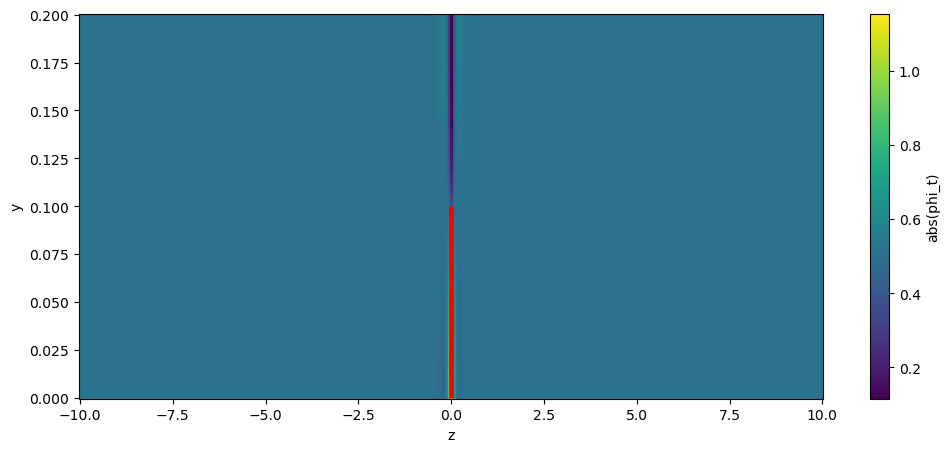

In [ ]:
# =========================
# ВИЗУАЛИЗАЦИЯ
# =========================
Phi_plot = np.abs(Phi_reflected)

plt.figure(figsize=(12, 5))

plt.pcolormesh(Z * 100.0, Y * 100.0, Phi_plot, shading='auto', cmap='viridis')

plt.xlabel('z')
plt.ylabel('y')
plt.colorbar(label='abs(phi_t)')

plt.vlines(0, 0, b* 100, colors='red', linewidth=3.5)
plt.show()

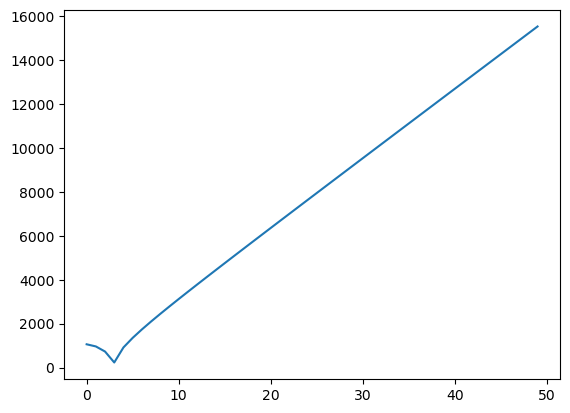

In [9]:
plt.plot(np.abs(gamma_n_half))

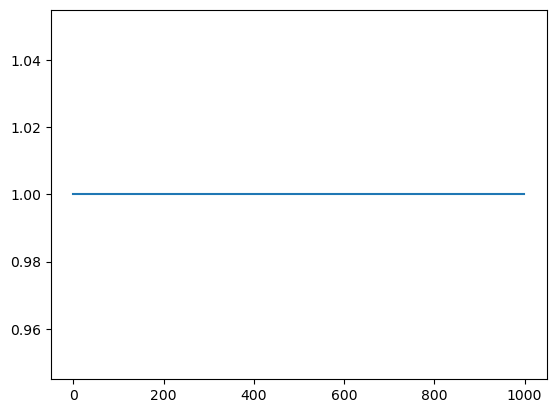

In [10]:
plt.plot(np.abs(np.exp(1j * k * z)))

In [11]:
k

(1074.048770458049+0j)

In [12]:
b

0.01

In [13]:
2*b*k

(21.48097540916098+0j)

In [27]:
2 * b / lmbd

0.3418803418803419